In [5]:
import pandas as pd
df = pd.read_csv("house_prices.csv")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   area  bedrooms  bathrooms  age  location_score    price
0   650         1          1   20               4  1850000
1   720         2          1   15               5  2150000
2   800         2          1   18               6  2400000
3   850         2          2   10               6  2650000
4   900         2          2   12               7  2900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            9 non-null      int64
 1   bedrooms        9 non-null      int64
 2   bathrooms       9 non-null      int64
 3   age             9 non-null      int64
 4   location_score  9 non-null      int64
 5   price           9 non-null      int64
dtypes: int64(6)
memory usage: 560.0 bytes
None
              area  bedrooms  bathrooms        age  location_score  \
count     9.000000  9.000000   9.000000   9.000000        9.000000   
mean    891.11

In [6]:
x=df[["area","bedrooms","bathrooms","age","location_score"]]
y=df["price"]
print(x.shape)
print(y.shape)

(9, 5)
(9,)


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
x,y,test_size=0.2,random_state=42
)
print("Train size:",x_train.shape[0])
print("Test size:",x_test.shape[0])

Train size: 7
Test size: 2


In [8]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("coefficients:",model.coef_)
print("Intercept:",model.intercept_)
y_pred=model.predict(x_test)
print(y_pred[ :5])
print(y_test.values[ :5])

coefficients: [  5454.54545455   8441.55844156 311038.96103896  42857.14285714
 -92857.14285714]
Intercept: -2503246.7532467507
[3342857.14285714 1930519.48051948]
[3650000 2150000]


In [9]:
from sklearn.metrics import(
 mean_absolute_error,mean_squared_error,r2_score
)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 263311.6883116886 MSE: 71254216562.65834 RMSE: 266934.8545294494 R2: 0.8733258372219408


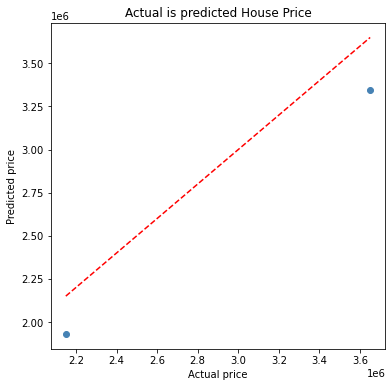

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,color="steelblue")
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual is predicted House Price")
plt.show()

In [14]:
x2=df[["area","bedrooms","location_score"]]
y2=df["price"]
x2_train,x2_test,y2_train,y2_test = train_test_split(
x2,y2,test_size=0.2,random_state=42
)
model2=LinearRegression()
model2.fit(x2_train,y2_train)
pred2=model2.predict(x2_test)
print("R2(3features):",r2_score(y2_test,pred2))
print("R2(5features):",r2)

R2(3features): 0.9811439818819685
R2(5features): 0.8733258372219408
